<a href="https://colab.research.google.com/github/hyeonji826/AI/blob/gen-vision/Yolov3_art_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import os, shutil, json, math, random, heapq, time
import numpy as np
import cv2
import csv
import statistics
import albumentations as A
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from pathlib import Path
from typing import List, Tuple, Dict
from torch.amp import autocast, GradScaler

In [52]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [53]:
root = "/content/data/Sample"
img_root = f"{root}/01.원천데이터"      # .jpg
lab_root = f"{root}/02.라벨링데이터"    # .json

dataset_root = "/content/dataset"
images_root = f"{dataset_root}/images"  # .jpg (전처리 후)
labels_root = f"{dataset_root}/labels"  # .txt

splits = ["train", "val"]

# 탐지

## 데이터 준비

In [54]:
# 초기화 후 CP949로 해제
!rm -rf /content/data && mkdir -p /content/data
!unzip -qq -O CP949 "/content/drive/MyDrive/Colab Notebooks/Python_colab/Web Service/생성형 AI/data/art.zip" -d /content/data

In [55]:
import glob
from pathlib import Path
random.seed(2025)

for split in ["train", "val"]:
    os.makedirs(f"{dataset_root}/images/{split}", exist_ok=True)
    os.makedirs(f"{dataset_root}/labels/{split}", exist_ok=True)

# 각 클래스 폴더 순회
classes = os.listdir(img_root)
for cls in classes:
    img_paths = sorted(glob.glob(f"{img_root}/{cls}/*.jpg"))
    lab_paths = sorted(glob.glob(f"{lab_root}/{cls}/*.json"))

    # 이름 기준 매칭
    pairs = [(i, l) for i, l in zip(img_paths, lab_paths) if Path(i).stem == Path(l).stem]
    random.shuffle(pairs)

    n = len(pairs)
    n_train = int(n*0.8)
    n_val   = n - n_train   # 나머지 전부 val

    split_data = {
        "train": pairs[:n_train],
        "val":   pairs[n_train:]
    }

    # 복사
    for split, items in split_data.items():
        for imgf, labf in items:
            shutil.copy(imgf, f"{dataset_root}/images/{split}/{Path(imgf).name}")
            shutil.copy(labf, f"{dataset_root}/labels/{split}/{Path(labf).name}")

print("데이터셋 분리 완료 ✅ (train=0.8, val=0.2)")

데이터셋 분리 완료 ✅ (train=0.8, val=0.2)


In [56]:
def convert_split_jsons(split: str, labels_root: str, class_to_id: dict):
    """
    split: "train" / "val"
    labels_root: dataset_root/labels
    class_to_id: {"cls_name": id}
    """
    split_dir = Path(labels_root) / split
    json_paths = sorted(glob.glob(str(split_dir / "*.json")))

    stats_rows = []
    for jp in json_paths:
        with open(jp, "r", encoding="utf-8") as f:
            J = json.load(f)

        # 해상도
        W,H = None,None
        if "meta" in J and "img_resolution" in J["meta"]:
            W,H = map(int, J["meta"]["img_resolution"].lower().split("x"))

        stem = Path(jp).stem
        yolo_txt = split_dir / f"{stem}.txt"
        lines = []

        for b in J.get("annotations", {}).get("bbox", []):
            lab = str(b.get("label", "")).strip()
            if lab not in class_to_id: continue
            cid = class_to_id[lab]
            x,y,w,h = [float(b[k]) for k in ("x","y","w","h")]
            cx = (x + w/2.0) / W
            cy = (y + h/2.0) / H
            nw, nh = w/W, h/H
            lines.append(f"{cid} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

            stats_rows.append({
                "split": split,
                "cls_name": lab,
                "cls_id": cid,
                "area_norm": nw*nh,
                "aspect": (nw/nh) if nh>0 else np.nan
            })

        if lines:
            with open(yolo_txt, "w", encoding="utf-8") as f:
                f.write("\n".join(lines))

    return pd.DataFrame(stats_rows)

# ===== 단일 클래스 매핑 (모든 라벨 -> 0) =====
class_to_id = {"__ALL__": 0}

# split별 변환
df_all = []
for split in ["train","val"]:
    df_all.append(convert_split_jsons(split, labels_root, class_to_id))

df = pd.concat(df_all, ignore_index=True)
print("[DONE] json→txt 변환 완료")

[DONE] json→txt 변환 완료


## 데이터 분석

- 클래스 불균형 존재 → 가중치나 oversampling 고려.

- 박스 대부분 소형, 일부는 전이미지 대형 객체 → 멀티스케일 + 앵커 재계산 필요.

- aspect 극단치 많음 → 앵커 다양하게 필요.

- train/val 분포 균형 잘 됨.

- 이미지당 객체 수 많음 → 후처리 튜닝(NMS, conf_thr) 중요.

## 데이터 전처리

### 1. 멀티스케일 + 앵커 계산

In [57]:
# ===== YOLOv3용 앵커 9개 산출 (IOU-kmeans) - 콘솔 출력 전용 =====
# 입력: labels_root (YOLO txt: cls cx cy w h, 모두 [0,1] normalized)
# 출력: anchors_norm(9,2), scale별(스몰/미디엄/라지) 배치, px 변환 프린트
def iou_matrix(boxes, centers):
    # boxes: (N,2), centers: (K,2)
    inter_w = np.minimum(boxes[:, 0:1], centers[None, :, 0])
    inter_h = np.minimum(boxes[:, 1:2], centers[None, :, 1])
    inter = inter_w * inter_h
    a_boxes = (boxes[:, 0:1] * boxes[:, 1:2])
    a_cent  = (centers[None, :, 0] * centers[None, :, 1])
    union = a_boxes + a_cent - inter + 1e-16
    return inter / union  # (N,K)

def _load_wh_from_labels(labels_root):
    ws, hs = [], []
    for txt in Path(labels_root).rglob("*.txt"):
        with open(txt, "r", encoding="utf-8") as f:
            for line in f:
                p = line.strip().split()
                if len(p) != 5: continue
                _, cx, cy, w, h = map(float, p)
                if w <= 0 or h <= 0 or w > 1 or h > 1: continue
                ws.append(w); hs.append(h)
    return np.stack([ws, hs], axis=1)

def _kmeans_pp_init(boxes, k, seed=2025):
    rng = np.random.default_rng(seed)
    n = boxes.shape[0]
    centers = np.empty((k,2), dtype=float)
    centers[0] = boxes[rng.integers(0, n)]
    # 초기 거리: 1 - max IoU(각 박스 vs 현재 센터들)
    d = 1.0 - iou_matrix(boxes, centers[:1]).max(axis=1)
    for c in range(1, k):
        probs = d**2
        probs /= (probs.sum() + 1e-16)
        idx = rng.choice(n, p=probs)
        centers[c] = boxes[idx]
        # 새 센터 추가 후 거리 갱신
        d = np.minimum(d, 1.0 - iou_matrix(boxes, centers[c:c+1]).squeeze(1))
    return centers

def kmeans_iou(boxes, k=9, max_iters=100, seed=2025):
    assert boxes.ndim == 2 and boxes.shape[1] == 2 and len(boxes) >= k
    centers = _kmeans_pp_init(boxes, k, seed=seed)
    last_assign = None
    for _ in range(max_iters):
        # (N,K) 거리 = 1 - IoU
        D = 1.0 - iou_matrix(boxes, centers)
        assign = D.argmin(axis=1)
        if last_assign is not None and np.all(assign == last_assign):
            break
        last_assign = assign
        for j in range(k):
            sel = boxes[assign == j]
            if len(sel) == 0:
                # 가장 먼 포인트로 재시드
                far_idx = D[:, j].argmax()
                centers[j] = boxes[far_idx]
            else:
                centers[j] = sel.mean(axis=0)
    return centers, assign

def avg_iou(boxes, clusters):
    return float(iou_matrix(boxes, clusters).max(axis=1).mean())

In [58]:
# ----- run -----
boxes = _load_wh_from_labels(labels_root)
print(f"총 박스 수: {len(boxes)}")
if len(boxes) < 9:
    raise SystemExit("박스가 9개 미만이어서 앵커 9개를 만들 수 없습니다.")

anchors, assign = kmeans_iou(boxes, k=9, max_iters=100, seed=2025)
# area 기준 오름차순 정렬
areas = anchors[:,0]*anchors[:,1]
order = np.argsort(areas)
anchors = anchors[order]

print("\n=== Anchors (normalized, k=9, area asc) ===")
for w,h in anchors:
    print(f"[{w:.5f}, {h:.5f}]")
print("평균 IoU:", f"{avg_iou(boxes, anchors):.4f}")

# YOLOv3 3-스케일 배치: P3(s8, small), P4(s16, medium), P5(s32, large)
P3 = anchors[:3]   # small
P4 = anchors[3:6]  # medium
P5 = anchors[6:9]  # large

def _fmt(arr):
    return "[" + ", ".join([f"({w:.5f},{h:.5f})" for w,h in arr]) + "]"

print("\n--- 스케일별 앵커 (normalized) ---")
print("P3 / stride=8  (small): ", _fmt(P3))
print("P4 / stride=16 (medium):", _fmt(P4))
print("P5 / stride=32 (large): ", _fmt(P5))

# px 변환 보기 좋은 몇 가지 입력 크기
img_sizes = [416, 512, 608]
for S in img_sizes:
    print(f"\n--- Anchors in px @img_size={S} ---")
    def to_px(a): return np.round(a*S).astype(int)
    print("P3:", to_px(P3))
    print("P4:", to_px(P4))
    print("P5:", to_px(P5))

총 박스 수: 13822

=== Anchors (normalized, k=9, area asc) ===
[0.03258, 0.03534]
[0.07146, 0.07168]
[0.08910, 0.17905]
[0.17698, 0.11186]
[0.19290, 0.25062]
[0.41010, 0.19537]
[0.29268, 0.47299]
[0.62586, 0.36169]
[0.54583, 0.78584]
평균 IoU: 0.6273

--- 스케일별 앵커 (normalized) ---
P3 / stride=8  (small):  [(0.03258,0.03534), (0.07146,0.07168), (0.08910,0.17905)]
P4 / stride=16 (medium): [(0.17698,0.11186), (0.19290,0.25062), (0.41010,0.19537)]
P5 / stride=32 (large):  [(0.29268,0.47299), (0.62586,0.36169), (0.54583,0.78584)]

--- Anchors in px @img_size=416 ---
P3: [[14 15]
 [30 30]
 [37 74]]
P4: [[ 74  47]
 [ 80 104]
 [171  81]]
P5: [[122 197]
 [260 150]
 [227 327]]

--- Anchors in px @img_size=512 ---
P3: [[17 18]
 [37 37]
 [46 92]]
P4: [[ 91  57]
 [ 99 128]
 [210 100]]
P5: [[150 242]
 [320 185]
 [279 402]]

--- Anchors in px @img_size=608 ---
P3: [[ 20  21]
 [ 43  44]
 [ 54 109]]
P4: [[108  68]
 [117 152]
 [249 119]]
P5: [[178 288]
 [381 220]
 [332 478]]


> 1. 앵커 9개 그대로 사용하면서 P3 -> P4 -> P5 배치 유지한다. 그리고 평균 IoU 0.6273을 시작치로 사용하되 나중에 성능보고 재클러스터링 해야할 수도 있음

> 2. 입력 크기 & 멀티 스케일은 (448,736), step = 64로 한다. 이유는 우리 데이터셋에서 소형 객체 비율이 많아서 해상도가 높아야할 것 같음


### 2. 이미지 전처리 및 증강

In [59]:
def preprocess_otsu_invert(img_bgr: np.ndarray) -> np.ndarray:
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # 선(보통 어두움)을 흰색으로 만들고 배경을 검정으로 -> THRESH_BINARY_INV
    _, binv = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 약한 블러로 에지 안정화 (너무 세게 하지 않음)
    binv = cv2.GaussianBlur(binv, (3, 3), 0)

    # 🔽 추가: 다시 hard binary로 확정 (0/255만 남음)
    _, binv = cv2.threshold(binv, 127, 255, cv2.THRESH_BINARY)

    # 단일 채널을 3채널로 확장 (모델 입력이 3채널일 경우)
    out = cv2.merge([binv, binv, binv])
    return out

# Albumentations hook 용 래퍼
def _preprocess_lambda(img, **kwargs):
    return preprocess_otsu_invert(img)

In [60]:
# 2) 증강: 작은 물체 보존 위주 (가벼운 기하 + 노이즈 약하게 + 밝기/대비 소폭)
#    - Mosaic/Copy-Paste는 낮은 확률. (CopyPaste만 기본 활성, Mosaic은 필요시 후에 추가)

def _bbox_passthrough_fn(bboxes, **kwargs):
    # 그대로 통과 (멀티프로세싱 호환)
    return bboxes

# 디버깅용: 박스 찍고 통과 (필요없으면 나중에 빼도 됨)
def _bbox_debug_print_fn(bboxes, **kwargs):
    # print("[DEBUG bbox]:", bboxes)
    return bboxes

# YOLO 라벨 포맷: [cls, cx, cy, w, h] (모두 [0,1])
bbox_params = A.BboxParams(
    format="yolo",
    label_fields=["class_labels"],
    min_visibility=0.2,
    clip=True
)

# 공통 전처리(항상 적용)
pre_base = A.Compose([
    A.Lambda(image=_preprocess_lambda, p=1.0),
    A.Lambda(bboxes=_bbox_passthrough_fn, p=1.0),   # ← lambda 제거(전역 함수 사용)
], bbox_params=bbox_params)

# 학습용 증강 (작은 물체 보존·경미 변환)
train_aug = A.Compose([
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent={"x": (-0.02, 0.02), "y": (-0.02, 0.02)},
        rotate=(-5, 5),
        shear={"x": (-5, 5), "y": (-3, 3)},
        fit_output=False,
        p=0.8
    ),
    A.Lambda(bboxes=_bbox_debug_print_fn, p=1.0),   # ← 함수명 오타 수정(_print_bboxes → _bbox_debug_print_fn)

    A.OneOf([
        A.GaussNoise(p=1.0),
        A.ISONoise(p=1.0),
    ], p=0.3),

    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
    ], p=0.15),

    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.15,
        p=0.5
    ),
], bbox_params=bbox_params)

# 검증용(전처리만)
val_aug = A.Compose([
    A.Lambda(bboxes=_bbox_passthrough_fn, p=1.0),    # ← _bbox_passthrough(람다) 대신 전역 함수 사용
], bbox_params=bbox_params)

In [61]:
# Letterbox
#    - 배경은 검정(0,0,0) 유지
def letterbox_for_size(target_hw=(608, 608)):
    th, tw = target_hw
    return A.Compose([
        A.LongestMaxSize(max_size=min(th, tw), interpolation=cv2.INTER_LINEAR, p=1.0),
        A.PadIfNeeded(
            min_height=th, min_width=tw,
            border_mode=cv2.BORDER_CONSTANT,
            fill=(0, 0, 0),     # ← value 대신 fill
            fill_mask=0,        # ← mask_value 대신 fill_mask
            p=1.0
        ),
    ], bbox_params=bbox_params)

In [62]:
# 랜덤 샘플 1개를 (이미지 경로, BGR이미지, YOLO bboxes, class_ids)로 반환
# - split: "train" / "val"
# - img_ext: 확장자 (필요시 변경)
import glob, random
from pathlib import Path
import cv2

def _load_sample(split="train", img_ext="jpg"):
    img_paths = glob.glob(str(Path(images_root, split, f"*.{img_ext}")))
    if not img_paths:
        print(f"[ERR] 이미지가 없습니다: {Path(images_root, split)}")
        return None
    img_path = random.choice(img_paths)
    lab_path = Path(labels_root, split, f"{Path(img_path).stem}.txt")

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"[ERR] 이미지를 읽지 못했습니다: {img_path}")
        return None

    boxes, cls_ids = [], []
    if lab_path.exists():
        with open(lab_path, "r", encoding="utf-8") as f:
            for line in f:
                p = line.strip().split()
                if len(p) != 5:
                    continue
                cid, cx, cy, w, h = p
                try:
                    cid = int(float(cid))
                    boxes.append([float(cx), float(cy), float(w), float(h)])  # YOLO 정규화(cx,cy,w,h)
                    cls_ids.append(cid)
                except Exception:
                    continue

    return img_path, img_bgr, boxes, cls_ids

In [63]:
# =========================
# 시각 디버그 유틸 (4분할 미리보기 + 요약)
#  - 원본
#  - 전처리 후
#  - 증강 #1
#  - 증강 #2 (확률 변환 차이 확인)
# =========================
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import random

def _draw_yolo_boxes(img_bgr, bboxes, color=(0, 255, 0), thickness=2, labels=None, font_scale=0.5):
    """bboxes: [ [cx,cy,w,h], ... ] (모두 [0,1]) 이미지 크기 기준으로 그림"""
    if img_bgr is None or len(bboxes) == 0:
        return img_bgr
    h, w = img_bgr.shape[:2]
    out = img_bgr.copy()
    for i, b in enumerate(bboxes):
        cx, cy, bw, bh = b[:4]
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        if labels is not None and i < len(labels):
            txt = str(labels[i])
            (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, font_scale, 1)
            cv2.rectangle(out, (x1, y1 - th - 4), (x1 + tw + 2, y1), color, -1)
            cv2.putText(out, txt, (x1, y1 - 3), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), 1, cv2.LINE_AA)
    return out

def _compare_boxes_np(a, b):
    """
    a,b: list of [cx,cy,w,h] (정규화)
    return: dict(str->float) 요약(평균/중앙 Δ와 비율)
    """
    if len(a) == 0 or len(b) == 0:
        return {"n": 0}
    K = min(len(a), len(b))
    A = np.array(a[:K])[:, :4]
    B = np.array(b[:K])[:, :4]
    d  = B - A                          # Δ(cx,cy,w,h)
    rw = (B[:,2] / (A[:,2] + 1e-9))     # w 비율
    rh = (B[:,3] / (A[:,3] + 1e-9))     # h 비율
    stat = {
        "n": K,
        "Δcx_mean": float(d[:,0].mean()), "Δcy_mean": float(d[:,1].mean()),
        "Δw_mean":  float(d[:,2].mean()), "Δh_mean":  float(d[:,3].mean()),
        "rw_med":   float(np.median(rw)), "rh_med":   float(np.median(rh)),
    }
    return stat

def preview_preproc_aug_once(split="train", force_affine=True, topk_print=5):
    """
    - 랜덤 샘플 1개 뽑아서 원본/전처리/증강2회 4분할로 시각화
    - force_affine=True면 Affine p=1.0으로 임시 강제 (증강 차이 바로 확인용)
    - 콘솔: 크기 정보 + Δ요약 + 앞 몇 개 박스 비교
    """
    sample = _load_sample(split)
    if sample is None:
        return
    img_path, img_bgr, boxes, cls_ids = sample
    if img_bgr is None:
        print("[ERR] 이미지를 읽지 못했습니다:", img_path); return

    print("=== PREVIEW ===")
    print("파일:", Path(img_path).name, "| 원본크기:", img_bgr.shape, "| 박스 수:", len(boxes))

    # 전처리
    out_pre = pre_base(image=img_bgr, bboxes=boxes, class_labels=cls_ids)
    img_pre, b_pre, l_pre = out_pre["image"], out_pre["bboxes"], out_pre["class_labels"]

    # 증강(두 번)
    # 필요 시 Affine p=1.0으로 강제하기 위해 임시로 교체
    if force_affine:
        aff = None
        new_t = []
        for tr in train_aug.transforms:
            if isinstance(tr, A.Affine):
                aff = A.Affine(
                    scale=tr.scale, translate_percent=tr.translate_percent,
                    rotate=tr.rotate, shear=tr.shear, fit_output=tr.fit_output, p=1.0
                )
                new_t.append(aff)
            else:
                new_t.append(tr)
        train_aug_forced = A.Compose(new_t, bbox_params=train_aug.processors["bboxes"].params)
        aug_fn = train_aug_forced
    else:
        aug_fn = train_aug

    out_aug1 = aug_fn(image=img_pre, bboxes=b_pre, class_labels=l_pre)
    img_aug1, b_aug1, l_aug1 = out_aug1["image"], out_aug1["bboxes"], out_aug1["class_labels"]

    out_aug2 = aug_fn(image=img_pre, bboxes=b_pre, class_labels=l_pre)
    img_aug2, b_aug2, l_aug2 = out_aug2["image"], out_aug2["bboxes"], out_aug2["class_labels"]

    # 콘솔 요약
    def _brief(gray):
        return {"bright>127": float((gray > 127).mean()),
                "edge": float((cv2.Canny(gray,100,200) > 0).mean())}

    g0 = cv2.cvtColor(img_bgr,  cv2.COLOR_BGR2GRAY)
    g1 = cv2.cvtColor(img_pre,  cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(img_aug1, cv2.COLOR_BGR2GRAY)
    g3 = cv2.cvtColor(img_aug2, cv2.COLOR_BGR2GRAY)

    print("[크기] 원본->전처리->증강1/2:", img_bgr.shape, "->", img_pre.shape, "->", img_aug1.shape, "/", img_aug2.shape)
    print("[원본] :", _brief(g0))
    print("[전처리]:", _brief(g1))
    print("[증강1] :", _brief(g2))
    print("[증강2] :", _brief(g3))

    stat12 = _compare_boxes_np(b_aug1, b_aug2)
    print("[증강1 vs 증강2] Δ요약:", stat12)

    # 앞 K개만 디테일 비교
    K = min(len(b_aug1), len(b_aug2), topk_print)
    if K > 0:
        print(f"[앞 {K}개 박스 Δ] (aug1 -> aug2)")
        for i in range(K):
            da = np.array(b_aug2[i][:4]) - np.array(b_aug1[i][:4])
            rw = (b_aug2[i][2] / (b_aug1[i][2] + 1e-9))
            rh = (b_aug2[i][3] / (b_aug1[i][3] + 1e-9))
            print(f"  #{i}: Δ={np.round(da,4).tolist()} | size≈({rw:.2f},{rh:.2f})")

    # --- 시각화 (4분할) ---
    # BGR->RGB 변환
    def _rgb(x): return cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

    vis0 = _draw_yolo_boxes(img_bgr,  boxes,  color=(0,255,0), labels=cls_ids)
    vis1 = _draw_yolo_boxes(img_pre,  b_pre,  color=(0,255,0), labels=l_pre)
    vis2 = _draw_yolo_boxes(img_aug1, b_aug1, color=(0,255,0), labels=l_aug1)
    vis3 = _draw_yolo_boxes(img_aug2, b_aug2, color=(0,255,0), labels=l_aug2)

    plt.figure(figsize=(12, 12))
    plt.subplot(2,2,1); plt.title("Original");   plt.imshow(_rgb(vis0)); plt.axis("off")
    plt.subplot(2,2,2); plt.title("Preprocessed"); plt.imshow(_rgb(vis1)); plt.axis("off")
    plt.subplot(2,2,3); plt.title("Aug#1");      plt.imshow(_rgb(vis2)); plt.axis("off")
    plt.subplot(2,2,4); plt.title("Aug#2");      plt.imshow(_rgb(vis3)); plt.axis("off")
    plt.tight_layout()
    plt.show()

=== PREVIEW ===
파일: 나무_11_남_08198.jpg | 원본크기: (1280, 1280, 3) | 박스 수: 14
[크기] 원본->전처리->증강1/2: (1280, 1280, 3) -> (1280, 1280, 3) -> (1280, 1280, 3) / (1280, 1280, 3)
[원본] : {'bright>127': 0.9809228515625, 'edge': 0.0142791748046875}
[전처리]: {'bright>127': 0.02754150390625, 'edge': 0.0111279296875}
[증강1] : {'bright>127': 0.026378173828125, 'edge': 0.26503662109375}
[증강2] : {'bright>127': 0.038963623046875, 'edge': 0.35134033203125}
[증강1 vs 증강2] Δ요약: {'n': 14, 'Δcx_mean': 0.02619977535902107, 'Δcy_mean': -0.03322626578383216, 'Δw_mean': -0.01248072180026101, 'Δh_mean': 0.006722538156957532, 'rw_med': 0.938812682387917, 'rh_med': 1.0265972630326168}
[앞 5개 박스 Δ] (aug1 -> aug2)
  #0: Δ=[0.0112, -0.0277, -0.0358, 0.0387] | size≈(0.93,1.05)
  #1: Δ=[0.0047, -0.0243, -0.0167, 0.0149] | size≈(0.93,1.05)
  #2: Δ=[0.0543, -0.05, -0.0226, -0.006] | size≈(0.95,0.98)
  #3: Δ=[0.0541, -0.0502, -0.0156, 0.0012] | size≈(0.94,1.01)
  #4: Δ=[-0.042, 0.0021, -0.0168, -0.0087] | size≈(0.95,0.95)


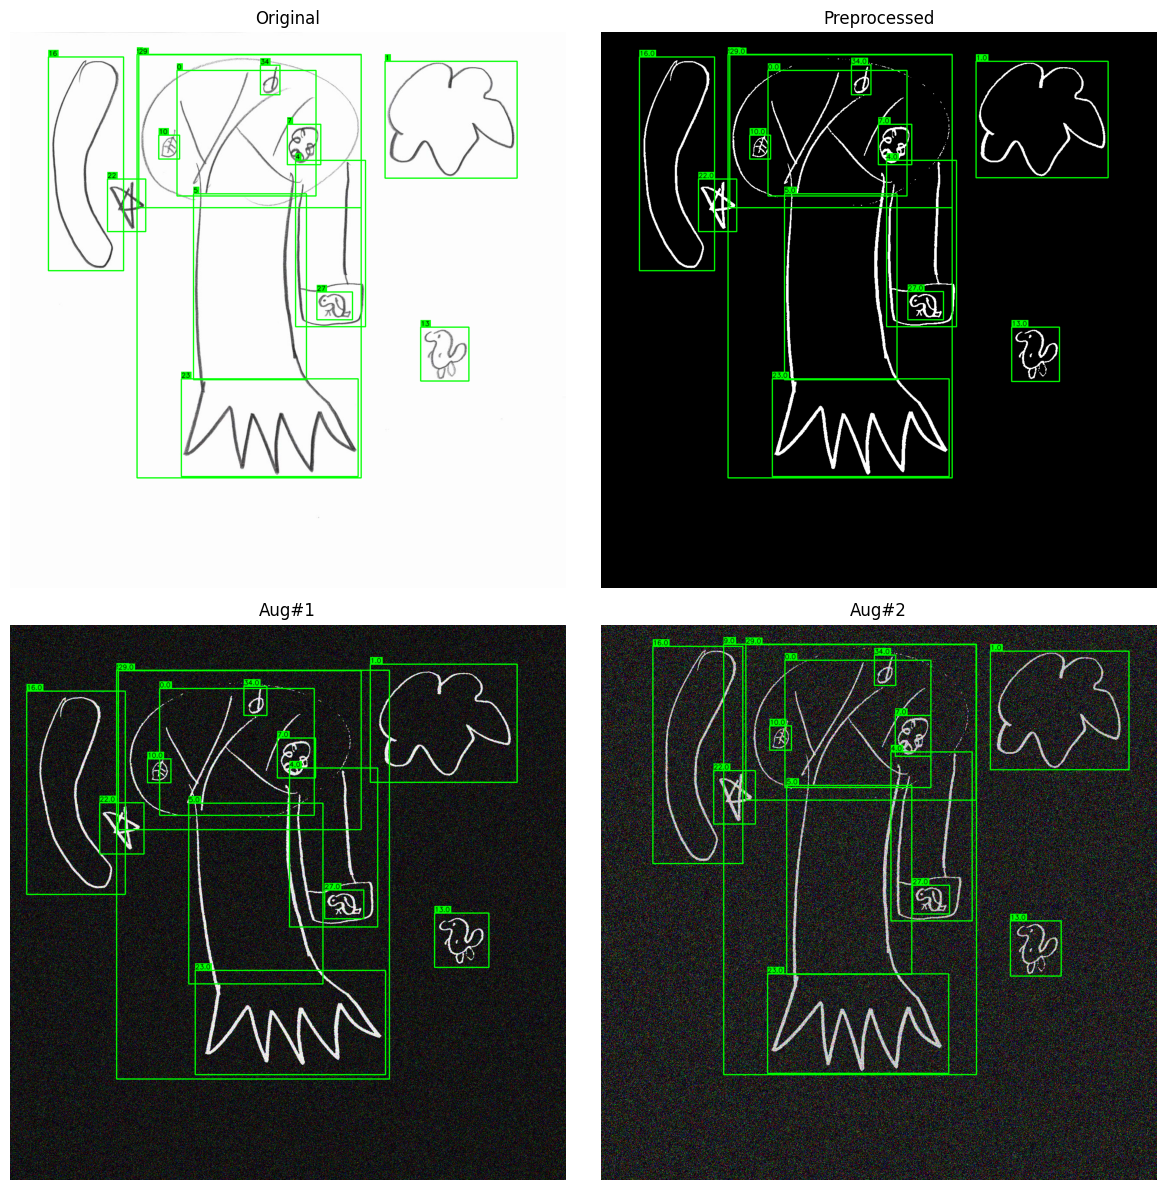

In [64]:
preview_preproc_aug_once(split="train", force_affine=True, topk_print=5)

## YOLOv3 + DarkNet-53 모델 구현

#### 1. 모델 구현(논문 기반 + 변형 -> RAM 폭발..)
[논문 링크](https://)

In [65]:
from torch.utils.checkpoint import checkpoint_sequential

def ckpt_seq(module: nn.Sequential, segments: int, x: torch.Tensor):
    # eval 모드이거나, grad 불필요하면 그대로 실행 (속도↑)
    if (not module.training) or (not x.requires_grad):
        return module(x)
    seg = max(1, min(segments, len(module)))
    return checkpoint_sequential(module, seg, x, use_reentrant=False)

In [66]:
# ---------- Building blocks ----------
class ConvBNAct(nn.Module):
    def __init__(self, c_in, c_out, k=1, s=1, p=None, groups=1):
        super().__init__()
        if p is None:
            p = (k - 1) // 2
        self.conv = nn.Conv2d(c_in, c_out, k, s, p, groups=groups, bias=False)
        self.bn   = nn.BatchNorm2d(c_out)
        self.act  = nn.LeakyReLU(0.1, inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class Residual(nn.Module):
    """Darknet residual: 1x1 reduce -> 3x3 expand + skip"""
    def __init__(self, c):
        super().__init__()
        c_half = c // 2
        self.cv1 = ConvBNAct(c, c_half, k=1, s=1)
        self.cv2 = ConvBNAct(c_half, c, k=3, s=1)
    def forward(self, x):
        return x + self.cv2(self.cv1(x))

class Darknet53(nn.Module):
    """Returns C3 (stride 8), C4 (stride 16), C5 (stride 32) feature maps."""
    def __init__(self):
        super().__init__()
        # stem
        self.cv1 = ConvBNAct(3, 32, k=3, s=1)
        # downsample to 64
        self.cv2 = ConvBNAct(32, 64, k=3, s=2)
        self.res1 = nn.Sequential(*[Residual(64) for _ in range(1)])
        # downsample to 128
        self.cv3 = ConvBNAct(64, 128, k=3, s=2)
        self.res2 = nn.Sequential(*[Residual(128) for _ in range(2)])
        # downsample to 256 (C3)
        self.cv4 = ConvBNAct(128, 256, k=3, s=2)
        self.res3 = nn.Sequential(*[Residual(256) for _ in range(8)])
        # downsample to 512 (C4)
        self.cv5 = ConvBNAct(256, 512, k=3, s=2)
        self.res4 = nn.Sequential(*[Residual(512) for _ in range(8)])
        # downsample to 1024 (C5)
        self.cv6 = ConvBNAct(512, 1024, k=3, s=2)
        self.res5 = nn.Sequential(*[Residual(1024) for _ in range(4)])

    def forward(self, x):
        x = self.cv1(x)
        x = self.cv2(x); x = self.res1(x)
        x = self.cv3(x); x = self.res2(x)
        x = self.cv4(x)
        # 여기서부터 체크포인트 적용(청크 수는 2~4 사이에서 시도)
        x = ckpt_seq(self.res3, segments=4, x=x); c3 = x      # stride 8
        x = self.cv5(x)
        x = ckpt_seq(self.res4, segments=4, x=x); c4 = x      # stride 16
        x = self.cv6(x)
        x = ckpt_seq(self.res5, segments=2, x=x); c5 = x      # stride 32
        return c3, c4, c5

def _make_convset(c_in, c_mid, c_out3x3):
    """(1x1,3x3,1x1,3x3,1x1) pattern used by YOLOv3 head."""
    return nn.Sequential(
        ConvBNAct(c_in,  c_mid,   k=1),
        ConvBNAct(c_mid, c_out3x3,k=3),
        ConvBNAct(c_out3x3, c_mid,k=1),
        ConvBNAct(c_mid, c_out3x3,k=3),
        ConvBNAct(c_out3x3, c_mid,k=1),
    )

In [67]:
# ---------- YOLOv3 Head ----------
class YOLOv3Head(nn.Module):
    def __init__(self, num_classes: int, anchors_norm: Dict[str, List[Tuple[float,float]]]):
        super().__init__()
        self.nc = num_classes
        self.strides = [8, 16, 32]

        # backbone
        self.backbone = Darknet53()

        # channel dims
        c3_ch, c4_ch, c5_ch = 256, 512, 1024

        # P5
        self.head5_1 = _make_convset(c5_ch, 512, 1024)
        self.det5_3x3 = ConvBNAct(512, 1024, k=3)
        self.det5_out = nn.Conv2d(1024, 3*(5+self.nc), 1)

        # P4
        self.trans5to4 = nn.Sequential(ConvBNAct(512, 256, k=1), nn.Upsample(scale_factor=2, mode='nearest'))
        self.head4_1 = _make_convset(c4_ch+256, 256, 512)
        self.det4_3x3 = ConvBNAct(256, 512, k=3)
        self.det4_out = nn.Conv2d(512, 3*(5+self.nc), 1)

        # P3
        self.trans4to3 = nn.Sequential(ConvBNAct(256, 128, k=1), nn.Upsample(scale_factor=2, mode='nearest'))
        self.head3_1 = _make_convset(c3_ch+128, 128, 256)
        self.det3_3x3 = ConvBNAct(128, 256, k=3)
        self.det3_out = nn.Conv2d(256, 3*(5+self.nc), 1)

        # anchors (normalized)
        default_anchors = {
            "P3": [(0.03258,0.03534),(0.07146,0.07168),(0.08910,0.17905)],
            "P4": [(0.17698,0.11186),(0.19290,0.25062),(0.41010,0.19537)],
            "P5": [(0.29268,0.47299),(0.62586,0.36169),(0.54583,0.78584)],
        }
        if anchors_norm is None:
            anchors_norm = default_anchors
        self.register_buffer("anchors_p3", torch.tensor(anchors_norm["P3"], dtype=torch.float32))  # (3,2)
        self.register_buffer("anchors_p4", torch.tensor(anchors_norm["P4"], dtype=torch.float32))
        self.register_buffer("anchors_p5", torch.tensor(anchors_norm["P5"], dtype=torch.float32))

        # grid cache {(H,W,device): (gx,gy)}
        self._grid_cache = {}

    # ----- helpers -----
    @staticmethod
    def _make_grid(H: int, W: int, device):
        yv, xv = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing="ij")
        grid_x = xv.view(1, 1, H, W).float()
        grid_y = yv.view(1, 1, H, W).float()
        return grid_x, grid_y

    def _get_grid(self, H: int, W: int, device):
        key = (H, W, device)
        if key not in self._grid_cache:
            self._grid_cache[key] = self._make_grid(H, W, device)
        return self._grid_cache[key]

    @staticmethod
    def _reshape_pred(p, nc):
        B, C, H, W = p.shape
        p = p.view(B, 3, 5+nc, H, W).permute(0,1,3,4,2).contiguous()
        return p  # (B,3,H,W,5+nc)

    def _decode_single(self, raw, anchors_norm, stride, in_hw):
        """
        returns: (raw_reshaped, decoded) with shape (B,3,H,W,5+nc)
        """
        device = raw.device
        dtype  = raw.dtype
        B, _, H, W = raw.shape

        # reshape logits -> (B,3,H,W,5+nc)
        p = self._reshape_pred(raw, self.nc)

        # cached grid
        gx, gy = self._get_grid(H, W, device)

        # anchors: normalized -> px -> grid units
        H_in, W_in = in_hw
        anc = anchors_norm.to(device=device, dtype=dtype)       # (3,2)
        anc_px = anc * torch.tensor([W_in, H_in], device=device, dtype=dtype)
        anc_g  = anc_px / float(stride)                         # (3,2)
        anchor_w = anc_g[:, 0].view(1, 3, 1, 1)
        anchor_h = anc_g[:, 1].view(1, 3, 1, 1)

        # split predictions
        tx = p[..., 0]; ty = p[..., 1]
        tw = p[..., 2]; th = p[..., 3]
        obj = torch.sigmoid(p[..., 4])
        cls = torch.sigmoid(p[..., 5:])

        # decode (정규화 좌표)
        cx = (torch.sigmoid(tx) + gx) / W
        cy = (torch.sigmoid(ty) + gy) / H
        bw = (torch.exp(tw) * anchor_w) / W
        bh = (torch.exp(th) * anchor_h) / H

        decoded = torch.cat([cx.unsqueeze(-1), cy.unsqueeze(-1),
                             bw.unsqueeze(-1), bh.unsqueeze(-1),
                             obj.unsqueeze(-1), cls], dim=-1)  # (B,3,H,W,5+nc)
        return p, decoded

    def forward(self, x):
        B, C, H_in, W_in = x.shape
        c3, c4, c5 = self.backbone(x)

        # P5
        y5  = self.head5_1(c5)
        det5 = self.det5_out(self.det5_3x3(y5))

        # P4
        up4 = self.trans5to4(y5)
        y4  = self.head4_1(torch.cat([up4, c4], dim=1))
        det4 = self.det4_out(self.det4_3x3(y4))

        # P3
        up3 = self.trans4to3(y4)
        y3  = self.head3_1(torch.cat([up3, c3], dim=1))
        det3 = self.det3_out(self.det3_3x3(y3))

        if self.training:
            return {"raw": [det3, det4, det5], "decoded": None}

        with torch.no_grad():
            _, d3 = self._decode_single(det3, self.anchors_p3, self.strides[0], (H_in, W_in))
            _, d4 = self._decode_single(det4, self.anchors_p4, self.strides[1], (H_in, W_in))
            _, d5 = self._decode_single(det5, self.anchors_p5, self.strides[2], (H_in, W_in))
        return {"raw": [det3, det4, det5], "decoded": [d3, d4, d5]}

> 앵커: 기본값은 산출한 9개(정규화). 다른 걸 쓰려면 anchors_norm에 같은 포맷으로 전달.

> 스트라이드: [8,16,32] 고정 (논문 구조 그대로)

> 활성함수: 백본/헤드 LeakyReLU(0.1), 클래스/오브젝트는 시그모이드(논문)

### 2. 타깃 매칭 & 로스 (논문기반)

- obj/cls: BCEWithLogitsLoss

- x,y: MSE( sigmoid(tx), t_x ), MSE( sigmoid(ty), t_y )

- w,h: MSE( tw, log(t_w/anchor_w) ), MSE( th, log(t_h/anchor_h) ) (grid 단위)

- ignore-mask: GT와 wh IoU가 ignore_iou 이상인 위치는 obj=0 손실에서 제외


In [68]:
# Helper: IoU for (w,h) only (그대로 사용)
def _iou_wh_torch(wh1, wh2):
    inter = torch.minimum(wh1[...,0], wh2[...,0]) * torch.minimum(wh1[...,1], wh2[...,1])
    a1 = wh1[...,0]*wh1[...,1]
    a2 = wh2[...,0]*wh2[...,1]
    return inter / (a1 + a2 - inter + 1e-16)

# ---------------------------
# Target builder (best of 9 anchors) - B 차원 포함 버전 (AMP/성능 보강)
# returns per-head dict:
#   txy [B,A,H,W,2], twh [B,A,H,W,2], tobj [B,A,H,W,1], tcls [B,A,H,W,C]
#   obj_mask [B,A,H,W], ignore_mask [B,A,H,W]
# ---------------------------
@torch.no_grad()
def build_targets_yolov3(targets, model, in_hw, num_classes, ignore_iou=0.5, device=None):
    # --- device/dtype 정합성 ---
    if device is None:
        try:
            device = next(model.parameters()).device
        except StopIteration:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    try:
        model_dtype = next(model.parameters()).dtype
    except StopIteration:
        model_dtype = torch.float32
    eps = torch.finfo(model_dtype).eps

    H_in, W_in = in_hw
    anchors = [model.anchors_p3, model.anchors_p4, model.anchors_p5]  # (3,2) normalized
    strides = model.strides  # [8,16,32]
    B = len(targets)

    # 헤드별 메타(그리드/앵커 grid-unit)
    head_meta = []
    for head_i in range(3):
        A = 3
        Hs = H_in // strides[head_i]
        Ws = W_in // strides[head_i]
        anc_norm = anchors[head_i].to(device=device, dtype=model_dtype)     # (3,2)
        anc_px   = anc_norm * torch.tensor([W_in, H_in], device=device, dtype=model_dtype)
        anc_g    = anc_px / float(strides[head_i])                          # (3,2)
        head_meta.append((A, Hs, Ws, anc_g))

    out = []
    for head_i in range(3):
        A, Hs, Ws, _ = head_meta[head_i]
        txy  = torch.zeros((B, A, Hs, Ws, 2), device=device, dtype=model_dtype)
        twh  = torch.zeros((B, A, Hs, Ws, 2), device=device, dtype=model_dtype)
        tobj = torch.zeros((B, A, Hs, Ws, 1), device=device, dtype=model_dtype)
        tcls = torch.zeros((B, A, Hs, Ws, num_classes), device=device, dtype=model_dtype)

        obj_m = torch.zeros((B, A, Hs, Ws), dtype=torch.bool, device=device)
        ign_m = torch.zeros((B, A, Hs, Ws), dtype=torch.bool, device=device)

        out.append({
            "txy": txy, "twh": twh, "tobj": tobj, "tcls": tcls,
            "obj_mask": obj_m, "ignore_mask": ign_m
        })

    # 모든 GT를 배치별로 매핑
    all_anc = torch.cat([a for a in anchors], dim=0).to(device=device, dtype=model_dtype)  # (9,2)

    for b, tgt in enumerate(targets):
        if tgt is None or len(tgt.get("boxes", [])) == 0:
            continue

        boxes  = tgt["boxes"].to(device=device, dtype=model_dtype).clamp(0, 1)  # (n,4) cx,cy,w,h
        labels = tgt["labels"].to(device=device, dtype=torch.long)               # (n,)

        # --- num_classes=1 안전 처리 (그 외에도 범위 클램프) ---
        if num_classes == 1:
            labels = torch.zeros_like(labels)
        else:
            labels.clamp_(0, num_classes - 1)

        n = boxes.size(0)
        if n == 0:
            continue

        # 9개 앵커 중 wh IoU 최대 선택
        ious  = _iou_wh_torch(boxes[:, 2:4].unsqueeze(1), all_anc.unsqueeze(0))  # (n,9)
        best9 = ious.argmax(dim=1)                                               # (n,)

        for i in range(n):
            a_global = int(best9[i].item())  # 0..8
            head_i   = a_global // 3         # 0..2
            a_local  = a_global % 3          # 0..2
            stride   = strides[head_i]
            A, Hs, Ws, anc_g = head_meta[head_i]

            cx, cy, w, h = boxes[i]

            gi = torch.clamp((cx * Ws).long(), 0, Ws - 1)
            gj = torch.clamp((cy * Hs).long(), 0, Hs - 1)

            # cell 내부 오프셋 (0..1)
            tx = cx * Ws - gi.to(model_dtype)
            ty = cy * Hs - gj.to(model_dtype)

            # 앵커 대비 log-space wh (grid 단위)
            aw_g = anc_g[a_local, 0]
            ah_g = anc_g[a_local, 1]
            w_g  = (w * W_in) / float(stride)
            h_g  = (h * H_in) / float(stride)
            tw = torch.log(torch.clamp(w_g / (aw_g + eps), min=eps))
            th = torch.log(torch.clamp(h_g / (ah_g + eps), min=eps))

            out[head_i]["txy"][b, a_local, gj, gi] = torch.stack([tx, ty])
            out[head_i]["twh"][b, a_local, gj, gi] = torch.stack([tw, th])
            out[head_i]["tobj"][b, a_local, gj, gi, 0] = 1.0
            out[head_i]["tcls"][b, a_local, gj, gi, int(labels[i].item())] = 1.0
            out[head_i]["obj_mask"][b, a_local, gj, gi] = True

            # ignore mask: 같은 셀에서 wh-IoU가 임계 이상인 앵커들
            for a_loc in range(3):
                iou_wh = _iou_wh_torch(
                    boxes[i, 2:4].unsqueeze(0),
                    anchors[head_i][a_loc].to(device=device, dtype=model_dtype).unsqueeze(0)
                ).item()
                if iou_wh >= ignore_iou:
                    out[head_i]["ignore_mask"][b, a_loc, gj, gi] = True

    return out

In [69]:
# YOLOv3 Loss (paper-style, device-agnostic, obj 정규화 적용)
class YoloV3Loss(nn.Module):
    def __init__(self, num_classes,
                 lambda_xy=1.0, lambda_wh=1.0,
                 lambda_obj=1.0, lambda_cls=0):
        super().__init__()
        self.num_classes = num_classes
        # reduction="sum" 유지, 최종에 배치/셀 등으로 정규화
        self.bce = nn.BCEWithLogitsLoss(reduction="sum")
        self.mse = nn.MSELoss(reduction="sum")
        self.lxy, self.lwh, self.lobj, self.lcls = lambda_xy, lambda_wh, lambda_obj, lambda_cls

    def forward(self, raw_heads, targets_built):
        """
        raw_heads: [det3, det4, det5], each (B, 3*(5+nc), H, W)
        targets_built: list of dicts (B 포함된 타겟)
        """
        B = raw_heads[0].shape[0]
        device = raw_heads[0].device
        dtype  = raw_heads[0].dtype

        if B == 0:
            zero = torch.zeros((), device=device, dtype=dtype)
            parts = {"xy":0.0,"wh":0.0,"obj":0.0,"cls":0.0,"total":0.0}
            return zero, parts

        total_xy = torch.zeros((), device=device, dtype=dtype)
        total_wh = torch.zeros((), device=device, dtype=dtype)
        total_obj = torch.zeros((), device=device, dtype=dtype)
        total_cls = torch.zeros((), device=device, dtype=dtype)

        # obj 정규화를 위한 전체 셀 수(배치 포함) 누적
        total_cells = 0  # sum over heads of (B * A * H * W), A=3

        for h_idx, p_logits in enumerate(raw_heads):
            tb = targets_built[h_idx]
            B_, C, Hs, Ws = p_logits.shape
            p = p_logits.view(B_, 3, 5 + self.num_classes, Hs, Ws)\
                        .permute(0, 1, 3, 4, 2).contiguous()

            # split
            tx, ty, tw, th, tobj = p[..., 0], p[..., 1], p[..., 2], p[..., 3], p[..., 4]
            tcls_logits = p[..., 5:]

            # targets (dtype/device 맞춤)
            obj_mask    = tb["obj_mask"].to(device)
            ign_mask    = tb["ignore_mask"].to(device)
            txy         = tb["txy"].to(device, dtype=dtype)
            twh         = tb["twh"].to(device, dtype=dtype)
            tobj_t      = tb["tobj"].squeeze(-1).to(device, dtype=dtype)
            tcls_onehot = tb["tcls"].to(device, dtype=dtype)

            # 전체 셀 수 누적 (배치 포함)
            total_cells += int(B_ * 3 * Hs * Ws)

            has_pos = obj_mask.any()
            if has_pos:
                # xy
                pred_xy = torch.stack([torch.sigmoid(tx), torch.sigmoid(ty)], dim=-1)
                mask5 = obj_mask.unsqueeze(-1).expand_as(pred_xy)
                total_xy = total_xy + self.mse(pred_xy[mask5].view(-1, 2),
                                               txy[mask5].view(-1, 2))

                # wh
                pred_wh = torch.stack([tw, th], dim=-1)
                total_wh = total_wh + self.mse(pred_wh[mask5].view(-1, 2),
                                               twh[mask5].view(-1, 2))

                # cls
                mask_cls = obj_mask.unsqueeze(-1).expand_as(tcls_logits)
                total_cls = total_cls + self.bce(
                    tcls_logits[mask_cls].view(-1, self.num_classes),
                    tcls_onehot[mask_cls].view(-1, self.num_classes)
                )

            # obj (pos+neg)
            neg_mask = (~obj_mask) & (~ign_mask)
            if has_pos:
                total_obj = total_obj + self.bce(tobj[obj_mask], tobj_t[obj_mask])
            if neg_mask.any():
                total_obj = total_obj + self.bce(tobj[neg_mask], tobj_t[neg_mask])

        # ── 정규화 ─────────────────────────────────────────────────────
        # obj는 '셀 평균'으로 정규화하여 스케일 과대 문제 완화
        if total_cells > 0:
            total_obj = total_obj / float(total_cells)

        # (선택) xy/wh/cls를 '양성 수'로 정규화하고 싶다면 아래 주석 해제
        pos_count = sum(tb["obj_mask"].to(device).sum().item() for tb in targets_built)
        pos_count = max(1, int(pos_count))
        total_xy  = total_xy  / float(pos_count)
        total_wh  = total_wh  / float(pos_count)
        total_cls = total_cls / float(pos_count)

        # 최종 합 (기존 인터페이스 유지: 배치로 평균)
        total = self.lxy*total_xy + self.lwh*total_wh + self.lobj*total_obj + self.lcls*total_cls
        invB = 1.0 / float(B)

        parts = {
            "xy":   float((total_xy * invB).detach().cpu()),
            "wh":   float((total_wh * invB).detach().cpu()),
            "obj":  float((total_obj * invB).detach().cpu()),  # obj는 이미 '셀 평균' 뒤 배치 평균
            "cls":  float((total_cls * invB).detach().cpu()),
            "total":float((total     * invB).detach().cpu()),
        }
        return total * invB, parts

### NMS & 평가 루프
- 모델 eval() 상태에서 decoded를 받아, 스코어= obj×max(cls) 로 NMS

- mAP@0.5, Precision/Recall,@0.5:0.95까지도 가능

In [70]:
import torch

def nms_boxes(boxes, scores, iou_thr=0.5):
    """
    boxes: (N,4) in xyxy normalized [0,1]
    scores: (N,)
    returns: kept indices (LongTensor)
    """
    if boxes.numel() == 0:
        return torch.empty((0,), dtype=torch.long, device=boxes.device)
    x1, y1, x2, y2 = boxes.unbind(1)
    areas = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    order = scores.argsort(descending=True)
    keep = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        xx1 = torch.maximum(x1[i], x1[rest])
        yy1 = torch.maximum(y1[i], y1[rest])
        xx2 = torch.minimum(x2[i], x2[rest])
        yy2 = torch.minimum(y2[i], y2[rest])
        inter = (xx2 - xx1).clamp(min=0) * (yy2 - yy1).clamp(min=0)
        iou = inter / (areas[i] + areas[rest] - inter + 1e-16)
        order = rest[iou <= iou_thr]
    return torch.tensor(keep, device=boxes.device, dtype=torch.long)

def _xywh_to_xyxy(xywh):
    cx, cy, w, h = xywh.unbind(-1)
    x1 = (cx - w * 0.5).clamp(0, 1)
    y1 = (cy - h * 0.5).clamp(0, 1)
    x2 = (cx + w * 0.5).clamp(0, 1)
    y2 = (cy + h * 0.5).clamp(0, 1)
    return torch.stack([x1, y1, x2, y2], dim=-1)

@torch.no_grad()
def evaluate_map50(model, dataloader, num_classes, conf_thr=0.25, nms_iou=0.45,
                   device="cuda", show_progress=False, pre_nms_topk=200,
                   class_agnostic=False):
    """
    간단 평가: mAP@0.5 근사치용 P/R/F1 (단일 conf_thr 포인트).
    - class_agnostic=True 면: 전역 NMS 단 1회, 예측/GT 클래스 모두 '0'으로 통일.
    - pre_nms_topk: NMS 전에 score 상위 K만 유지 (전역, per-image)
    """
    model.eval()
    use_cuda_amp = (device == "cuda")

    nC_eval = 1 if class_agnostic else num_classes
    all_tp = [0] * nC_eval
    all_fp = [0] * nC_eval
    all_fn = [0] * nC_eval
    eps = 1e-9

    def iou_xyxy(a, b):
        N, M = a.size(0), b.size(0)
        if N == 0 or M == 0:
            return torch.zeros((N, M), device=a.device)
        xx1 = torch.maximum(a[:, 0:1], b[:, 0])
        yy1 = torch.maximum(a[:, 1:2], b[:, 1])
        xx2 = torch.minimum(a[:, 2:3], b[:, 2])
        yy2 = torch.minimum(a[:, 3:4], b[:, 3])
        inter = (xx2 - xx1).clamp(min=0) * (yy2 - yy1).clamp(min=0)
        area_a = (a[:, 2] - a[:, 0]).clamp(min=0) * (a[:, 3] - a[:, 1]).clamp(min=0)
        area_b = (b[:, 2] - b[:, 0]).clamp(min=0) * (b[:, 3] - b[:, 1]).clamp(min=0)
        return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-16)

    iterator = tqdm(dataloader, desc="Eval", leave=False) if show_progress else dataloader
    for batch in iterator:
        imgs = batch["images"].to(device, non_blocking=True)
        targets = batch["targets"]

        with torch.amp.autocast("cuda", enabled=use_cuda_amp):
            out = model(imgs)
            d3, d4, d5 = out["decoded"]

        B = imgs.size(0)
        for b in range(B):
            preds_list = []
            for d in (d3[b], d4[b], d5[b]):  # (A,H,W,5+nc)
                A, Hs, Ws, _ = d.shape
                dv = d.view(-1, 5 + num_classes)
                if dv.numel() == 0:
                    continue
                xywh = dv[:, :4]
                obj  = dv[:, 4]
                cls  = dv[:, 5:]
                cls_score, cls_idx = cls.max(dim=1)
                score = obj * cls_score
                keep = score > conf_thr
                if keep.any():
                    xyxy = _xywh_to_xyxy(xywh[keep])
                    if class_agnostic:
                        cls_col = torch.zeros_like(cls_idx[keep].float())
                    else:
                        cls_col = cls_idx[keep].float()
                    preds_list.append(torch.cat([xyxy, score[keep, None], cls_col[:, None]], dim=1))
            preds = torch.cat(preds_list, dim=0) if preds_list else torch.empty((0, 6), device=imgs.device)

            # pre-NMS Top-K
            if preds.shape[0] > pre_nms_topk:
                topk_idx = torch.topk(preds[:, 4], k=pre_nms_topk, largest=True, sorted=False).indices
                preds = preds[topk_idx]

            # NMS
            if class_agnostic:
                if preds.numel() > 0:
                    keep_idx = nms_boxes(preds[:, :4], preds[:, 4], iou_thr=nms_iou)
                    final_preds = preds[keep_idx]
                    if final_preds.numel() > 0:
                        final_preds[:, 5] = 0.0  # 보장
                else:
                    final_preds = torch.empty((0, 6), device=imgs.device)
            else:
                final_preds = []
                for c in range(num_classes):
                    if preds.numel() == 0:
                        continue
                    cls_mask = (preds[:, 5].to(torch.long) == c)
                    P = preds[cls_mask]
                    if P.numel() == 0:
                        continue
                    keep_idx = nms_boxes(P[:, :4], P[:, 4], iou_thr=nms_iou)
                    if keep_idx.numel() > 0:
                        final_preds.append(P[keep_idx])
                final_preds = torch.cat(final_preds, dim=0) if final_preds else torch.empty((0, 6), device=imgs.device)

            # GT
            tgt = targets[b]
            if tgt is None or len(tgt.get("boxes", [])) == 0:
                if final_preds.numel() > 0:
                    if class_agnostic:
                        all_fp[0] += int(final_preds.shape[0])
                    else:
                        cls_ids = final_preds[:, 5].to(torch.long)
                        for c in range(num_classes):
                            all_fp[c] += int((cls_ids == c).sum().item())
                continue

            gt_xyxy = _xywh_to_xyxy(tgt["boxes"].to(imgs.device))
            gt_cls  = tgt["labels"].to(imgs.device).long()
            if class_agnostic:
                gt_cls = torch.zeros_like(gt_cls)
            matched = torch.zeros(gt_cls.shape[0], dtype=torch.bool, device=imgs.device)

            for c in range(nC_eval):
                P = final_preds[final_preds[:, 5].to(torch.long) == c]
                idxs = torch.nonzero(gt_cls == c, as_tuple=False).squeeze(1)

                if idxs.numel() == 0:
                    if P.numel() > 0:
                        all_fp[c] += int(P.shape[0])
                    continue
                if P.numel() == 0:
                    all_fn[c] += int(idxs.numel())
                    continue

                ious = iou_xyxy(P[:, :4], gt_xyxy[idxs])
                for pi in range(P.shape[0]):
                    j = int(ious[pi].argmax().item())
                    iou = float(ious[pi, j].item())
                    gt_j = idxs[j]
                    if iou >= 0.5 and not matched[gt_j]:
                        matched[gt_j] = True
                        all_tp[c] += 1
                    else:
                        all_fp[c] += 1
                all_fn[c] += int((~matched[idxs]).sum().item())

    # metrics (macro over nC_eval)
    metrics = {}
    for c in range(nC_eval):
        TP, FP, FN = all_tp[c], all_fp[c], all_fn[c]
        P = TP / (TP + FP + eps)
        R = TP / (TP + FN + eps)
        F1 = 2 * P * R / (P + R + eps)
        metrics[c] = {"TP": TP, "FP": FP, "FN": FN, "P": P, "R": R, "F1": F1}

    Pm = sum(m["P"] for m in metrics.values()) / max(1, nC_eval)
    Rm = sum(m["R"] for m in metrics.values()) / max(1, nC_eval)
    Fm = sum(m["F1"] for m in metrics.values()) / max(1, nC_eval)
    return {"per_class": metrics, "macro": {"P": Pm, "R": Rm, "F1": Fm}}

## 학습+평가 Loop

- 전처리·증강: pre_base / train_aug / val_aug
- 모델: YOLOv3Head
- 로스/타깃: build_targets_yolov3, YoloV3Loss
- 평가: evaluate_map50

#### 함수

In [71]:
import gc

# 0) 유틸: 시드 고정 / EMA / 스케줄러
def seed_random(seed=2025, deterministic=True):
    import os, random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Python 해시 난수 고정
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 재현성 강화
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        # 결정적 알고리즘만 사용 (일부 연산 미지원 시 오류 가능)
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.benchmark = True

class EMA:
    """Exponential Moving Average of model parameters (device/dtype-safe)."""
    def __init__(self, model: torch.nn.Module, decay: float = 0.9998):
        self.model = model
        self.decay = float(decay)
        self.shadow = {}   # name -> tensor (same dtype/device as param)
        self.backup = None
        with torch.no_grad():
            for n, p in model.named_parameters():
                if p.requires_grad:
                    self.shadow[n] = p.detach().clone()

    @torch.no_grad()
    def update(self):
        # shadow = decay*shadow + (1-decay)*param
        d = self.decay
        for n, p in self.model.named_parameters():
            if not p.requires_grad:
                continue
            s = self.shadow[n]
            # 디바이스/타입 차이가 나면 맞춰줌
            if s.device != p.device or s.dtype != p.dtype:
                self.shadow[n] = s.to(device=p.device, dtype=p.dtype)
                s = self.shadow[n]
            s.lerp_(p.detach(), 1.0 - d)  # s = s*(d) + p*(1-d)

    @torch.no_grad()
    def apply_shadow(self):
        # 현재 파라미터를 백업하고 EMA 파라미터를 적용
        self.backup = {}
        for n, p in self.model.named_parameters():
            if not p.requires_grad:
                continue
            self.backup[n] = p.detach().clone()
            ema_t = self.shadow[n]
            if ema_t.device != p.device or ema_t.dtype != p.dtype:
                ema_t = ema_t.to(device=p.device, dtype=p.dtype)
            p.data.copy_(ema_t)

    @torch.no_grad()
    def restore(self):
        # 백업 복원
        if self.backup is None:
            return
        for n, p in self.model.named_parameters():
            if not p.requires_grad:
                continue
            p.data.copy_(self.backup[n])
        self.backup = None

    # 편의: with ema.activate():  # EMA weight로 평가
    from contextlib import contextmanager
    @contextmanager
    def activate(self):
        self.apply_shadow()
        try:
            yield
        finally:
            self.restore()

def cosine_lr_scheduler(optimizer, base_lr, min_lr, T_total, warmup_iters=0):
    """Return a LambdaLR (warmup + cosine decay)."""
    base_lr = float(base_lr)
    min_lr  = float(min_lr)
    def lr_lambda(it):
        if it < warmup_iters:
            return (it + 1) / max(1, warmup_iters)
        t = (it - warmup_iters) / max(1, T_total - warmup_iters)
        #  min_lr = base_lr * min_scale  -> scale = min_lr/base_lr
        min_scale = min_lr / base_lr
        return min_scale + 0.5*(1 - min_scale)*(1 + math.cos(math.pi * t))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [72]:
seed_random(2025)

device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = 1

# 데이터로더
img_size = 608   # 기본 입력 크기
batch_size = 4   # VRAM에 맞게 조절
num_workers = 0

lb_train = letterbox_for_size((img_size, img_size))
lb_val   = letterbox_for_size((img_size, img_size))

print(device, img_size, batch_size, num_classes)

cpu 608 4 1


In [73]:
class YoloDataset(Dataset):
    def __init__(self, images_root, labels_root, split="train", img_ext="jpg", is_train=True, num_classes=1):
        self.images = sorted(list(Path(images_root, split).glob(f"*.{img_ext}")))
        self.labels_root = Path(labels_root, split)
        self.is_train = is_train
        self.num_classes = num_classes  # 없으면 체크 생략

    def __len__(self):
        return len(self.images)

    def _read_labels(self, stem):
        p = self.labels_root / f"{stem}.txt"
        boxes, cls_ids = [], []
        if p.exists():
            with open(p, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cid, cx, cy, w, h = parts
                    cid = int(float(cid))
                    bx = [float(cx), float(cy), float(w), float(h)]
                    # (선택) 클래스 범위 체크
                    if self.num_classes is not None and not (0 <= cid < self.num_classes):
                        continue
                    boxes.append(bx)
                    cls_ids.append(cid)
        return boxes, cls_ids

    def __getitem__(self, idx):
        imp = str(self.images[idx])

        # --- 흑백 이미지 안전 처리: 1채널 -> 3채널로 확장 ---
        img_gray = cv2.imread(imp, cv2.IMREAD_GRAYSCALE)  # HxW (uint8)
        if img_gray is None:
            raise RuntimeError(f"Failed to read image: {imp}")
        img = cv2.merge([img_gray, img_gray, img_gray])   # HxWx3 (BGR 모사)

        h, w = img.shape[:2]
        stem = Path(imp).stem
        boxes, cls_ids = self._read_labels(stem)

        # 1) 전처리
        out = pre_base(image=img, bboxes=boxes, class_labels=cls_ids)
        img, bbs, cls = out["image"], out["bboxes"], out["class_labels"]

        # 2) 증강 (학습만)
        out2 = (train_aug if self.is_train else val_aug)(image=img, bboxes=bbs, class_labels=cls)
        img2, bbs2, cls2 = out2["image"], out2["bboxes"], out2["class_labels"]

        # 3) 레터박스
        lb = lb_train if self.is_train else lb_val
        lb_out = lb(image=img2, bboxes=bbs2, class_labels=cls2)
        img2, bbs2, cls2 = lb_out["image"], lb_out["bboxes"], lb_out["class_labels"]

        # 4) 텐서 변환 [H,W,3] -> [3,H,W], 0..1 float32
        img2 = (img2.astype(np.float32) / 255.0)
        img2 = np.transpose(img2, (2, 0, 1))
        img2 = np.ascontiguousarray(img2)
        img_t = torch.from_numpy(img2)

        # target dict (cxcywh in [0,1])
        if len(bbs2) > 0:
            boxes_t = torch.tensor(bbs2, dtype=torch.float32)
            labels_t = torch.tensor(cls2, dtype=torch.long)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.long)

        target = {"boxes": boxes_t, "labels": labels_t, "image_id": stem, "orig_size": (h, w)}
        return img_t, target

def yolo_collate(batch):
    imgs, tgts = zip(*batch)
    imgs = torch.stack(imgs, dim=0)  # (B,3,H,W)
    return {"images": imgs, "targets": list(tgts)}

In [74]:
@torch.no_grad()
def detect_on_image_path(
    image_path: str,
    model,                      # YOLOv3Head
    device=None,                # None → model/device auto
    conf_thr=0.25,
    nms_iou=0.5,
    num_classes=None,           # None → model.nc
    class_names=None
):
    """
    단일 이미지 경로를 받아 탐지 결과 반환.
    반환 dict:
      - boxes_xyxy: (N,4) float32, pixel coords
      - scores:     (N,)  float32
      - labels:     (N,)  int64
      - names:      list[str]
    """
    # --- device 결정 (CPU/CUDA 전환 자유) ---
    if device is None:
        try:
            device = next(model.parameters()).device
        except StopIteration:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)
    use_cuda_amp = (device.type == "cuda" and torch.cuda.is_available())

    # --- 이미지 로드 (흑백 대응: 1ch -> 3ch) ---
    img_bgr = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_bgr is None:
        raise RuntimeError(f"Failed to read: {image_path}")
    if img_bgr.ndim == 2 or (img_bgr.ndim == 3 and img_bgr.shape[2] == 1):
        img_bgr = cv2.merge([img_bgr, img_bgr, img_bgr])
    H0, W0 = img_bgr.shape[:2]

    # --- 전처리/검증 증강/레터박스 ---
    img = pre_base(image=img_bgr, bboxes=[], class_labels=[])["image"]
    img = val_aug(image=img, bboxes=[], class_labels=[])["image"]
    img = lb_val(image=img, bboxes=[], class_labels=[])["image"]

    # --- 텐서 변환 ---
    arr = (img.astype(np.float32) / 255.0)
    arr = np.transpose(arr, (2, 0, 1))
    x = torch.from_numpy(np.ascontiguousarray(arr)).unsqueeze(0).to(device)

    # --- 모델 추론 (AMP on CUDA만) ---
    model = model.to(device).eval()
    with torch.amp.autocast(device_type="cuda", enabled=use_cuda_amp):
        out = model(x)
        decoded = out.get("decoded", None)
        if decoded is None:  # 학습모드로 호출된 경우 방어적 디코드
            B, _, H_in, W_in = x.shape
            _, d3 = model._decode_single(out["raw"][0], model.anchors_p3, model.strides[0], (H_in, W_in))
            _, d4 = model._decode_single(out["raw"][1], model.anchors_p4, model.strides[1], (H_in, W_in))
            _, d5 = model._decode_single(out["raw"][2], model.anchors_p5, model.strides[2], (H_in, W_in))
            decoded = [d3, d4, d5]

    nC = model.nc if num_classes is None else int(num_classes)

    # --- 후처리: 통합 → conf filter → per-class NMS ---
    preds_list = []
    for d in decoded:
        d = d[0]  # (A,Hs,Ws,5+nc), batch=1
        if d.numel() == 0:
            continue
        flat = d.reshape(-1, 5 + nC)
        xywh = flat[:, :4]
        obj  = flat[:, 4]
        cls  = flat[:, 5:]
        cls_score, cls_idx = cls.max(dim=1)
        score = obj * cls_score
        keep = score > conf_thr
        if keep.any():
            xyxy = _xywh_to_xyxy(xywh[keep])  # normalized
            preds_list.append(torch.cat([xyxy, score[keep, None], cls_idx[keep, None].float()], dim=1))

    preds = torch.cat(preds_list, dim=0) if preds_list else torch.empty((0, 6), device=device)

    final = []
    for c in range(nC):
        PC = preds[preds[:, 5].to(torch.long) == c]
        if PC.numel() == 0:
            continue
        keep = nms_boxes(PC[:, :4], PC[:, 4], iou_thr=nms_iou)
        if keep.numel() > 0:
            final.append(PC[keep])
    final = torch.cat(final, dim=0) if final else torch.empty((0, 6), device=device)

    # --- 정규화 → 원본 픽셀 좌표 (간단 매핑) ---
    if final.numel() == 0:
        return {
            "boxes_xyxy": np.zeros((0, 4), dtype=np.float32),
            "scores": np.zeros((0,), dtype=np.float32),
            "labels": np.zeros((0,), dtype=np.int64),
            "names": []
        }

    xyxy = final[:, :4].clamp(0, 1)
    x1 = (xyxy[:, 0] * W0).round().detach().cpu().numpy()
    y1 = (xyxy[:, 1] * H0).round().detach().cpu().numpy()
    x2 = (xyxy[:, 2] * W0).round().detach().cpu().numpy()
    y2 = (xyxy[:, 3] * H0).round().detach().cpu().numpy()
    boxes_px = np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)

    scores = final[:, 4].detach().cpu().numpy().astype(np.float32)
    labels = final[:, 5].to(torch.long).detach().cpu().numpy()

    names = [class_names[int(i)] if (class_names is not None and 0 <= int(i) < len(class_names)) else str(int(i))
             for i in labels]

    return {"boxes_xyxy": boxes_px, "scores": scores, "labels": labels, "names": names}

#### 하이퍼파라미터

In [75]:
# 2) 하이퍼파라미터 & 로더/모델/옵티마 세팅
from math import ceil

# ── Dataset / DataLoader ─────────────────────────────────────────────
train_ds = YoloDataset(images_root, labels_root, split="train", is_train=True)
val_ds   = YoloDataset(images_root, labels_root, split="val",   is_train=False)

use_cuda = (device == "cuda" and torch.cuda.is_available())
pin_mem  = True if use_cuda else False
persist  = True if (num_workers > 0) else False  # worker 유지(속도↑)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_mem,
    collate_fn=yolo_collate,
    persistent_workers=persist
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_mem,
    collate_fn=yolo_collate,
    persistent_workers=persist
)

# ── 모델 ─────────────────────────────────────────────────────────────
model = YOLOv3Head(num_classes=num_classes, anchors_norm=None).to(device)

# ── 손실 (작은 물체 비중 ↑) ─────────────────────────────────────────
criterion = YoloV3Loss(
    num_classes=num_classes,
    lambda_xy=2.0, lambda_wh=2.0,
    lambda_obj=1.5, lambda_cls=0
)

# ── Optimizer & Scheduler (업데이트 단위 스케줄링) ──────────────────
base_lr = 1e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=5e-4)

epochs = 40
warmup_epochs = 3
grad_accum = 8  # 유효 배치 = batch_size * grad_accum

steps_per_epoch   = max(1, len(train_loader))
updates_per_epoch = ceil(steps_per_epoch / grad_accum)     # optimizer.step() 호출 수
max_updates       = epochs * updates_per_epoch
warmup_updates    = warmup_epochs * updates_per_epoch

scheduler = cosine_lr_scheduler(
    optimizer,
    base_lr=base_lr,
    min_lr=base_lr * 0.05,
    T_total=max_updates,
    warmup_iters=warmup_updates
)
# ※ 학습 루프에서 optimizer.step() 할 때만 scheduler.step() 호출하세요.

# ── EMA ──────────────────────────────────────────────────────────────
ema = EMA(model, decay=0.9998)

# ── AMP & 백엔드 세팅 ────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)
if use_cuda:
    torch.backends.cudnn.benchmark = True   # 입력 크기 고정이면 성능↑
try:
    torch.set_float32_matmul_precision('medium')  # PyTorch 2.x (가능한 경우)
except Exception:
    pass

# ── 출력 디렉토리 ───────────────────────────────────────────────────
out_dir = Path(dataset_root) / "runs_yolov3"
out_dir.mkdir(parents=True, exist_ok=True)
best_path = out_dir / "best.pt"

print(f"[cfg] device={device} | classes={num_classes} | img_size={img_size} | "
      f"batch={batch_size}x{grad_accum} | epochs={epochs} | workers={num_workers} | pin_memory={pin_mem}")

[cfg] device=cpu | classes=1 | img_size=608 | batch=4x8 | epochs=40 | workers=0 | pin_memory=False


/tmp/ipython-input-1497443198.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)


In [76]:
batch = next(iter(train_loader))
images, targets = batch["images"], batch["targets"]

print("images:", images.shape)
print("targets:", type(targets), len(targets))
print("첫 번째 타깃 keys:", targets[0].keys())
print("첫 번째 boxes shape:", targets[0]["boxes"].shape)
print("첫 번째 labels shape:", targets[0]["labels"].shape)

images: torch.Size([4, 3, 608, 608])
targets: <class 'list'> 4
첫 번째 타깃 keys: dict_keys(['boxes', 'labels', 'image_id', 'orig_size'])
첫 번째 boxes shape: torch.Size([0, 4])
첫 번째 labels shape: torch.Size([0])


### 스모크 테스트

In [77]:
# 스모크: 한 배치로 순전파/손실/역전파 1회 (CPU 설정에 맞춤)
model.train()
batch = next(iter(train_loader))
imgs, tlist = batch["images"].to(device), batch["targets"]

# 모델 순전파 (학습 모드라 decoded=None, raw만 반환)
out = model(imgs)
raw_heads = out["raw"]  # [det3, det4, det5]

# 타깃 빌드
in_hw = (imgs.shape[2], imgs.shape[3])  # (H, W) = (608, 608)
tbuilt = build_targets_yolov3(tlist, model, in_hw, num_classes, device=device)

# 손실 계산
loss, parts = criterion(raw_heads, tbuilt)
print("loss parts:", parts)

# 역전파 (CPU라 AMP/Scaler 자동 비활성)
optimizer.zero_grad(set_to_none=True)
loss.backward()
optimizer.step()

loss parts: {'xy': 0.0, 'wh': 0.0, 'obj': 0.19125010073184967, 'cls': 0.0, 'total': 0.2868751585483551}


### 디버깅

In [78]:
# ===== Debug: 구성/파이프라인/하이퍼 파라미터 요약 =====
def _alb_list(trans):
    try:
        return [t.__class__.__name__ for t in trans.transforms]
    except Exception:
        return ["<unknown>"]

def dump_setup_summary(model, train_loader, val_loader,
                       img_size, batch_size, epochs, base_lr,
                       scheduler, optimizer, ema, grad_accum,
                       ignore_iou=0.5, conf_thr_eval=0.25, nms_iou=0.5,
                       pre_nms_topk=300):
    dev = next(model.parameters()).device
    print("=== SETUP SUMMARY ===")
    print(f"[Device] {dev} | channels_last(CUDA only)={'cuda'==dev.type}")
    print(f"[Data] train={len(train_loader.dataset)} images, val={len(val_loader.dataset)} images")
    print(f"[Loader] train batch={train_loader.batch_size}, workers={train_loader.num_workers}, pin={train_loader.pin_memory}")
    print(f"[Loader]   val batch={val_loader.batch_size}, workers={val_loader.num_workers}, pin={val_loader.pin_memory}")
    print(f"[Model] strides={model.strides} | classes={model.nc} | img_size={img_size}")
    print(f"[Anchors P3] {model.anchors_p3.detach().cpu().numpy().tolist()}")
    print(f"[Anchors P4] {model.anchors_p4.detach().cpu().numpy().tolist()}")
    print(f"[Anchors P5] {model.anchors_p5.detach().cpu().numpy().tolist()}")
    print(f"[Optim] {optimizer.__class__.__name__}, base_lr={base_lr:.3e}, wd={optimizer.param_groups[0].get('weight_decay', 0)}")
    print(f"[Sched] {scheduler.__class__.__name__}")
    print(f"[EMA] decay={getattr(ema, 'decay', None)}")
    print(f"[Loop] epochs={epochs}, grad_accum={grad_accum}")
    print(f"[Loss λ] xy={criterion.lxy}, wh={criterion.lwh}, obj={criterion.lobj}, cls={criterion.lcls}")
    print(f"[Target] ignore_iou={ignore_iou}")
    print(f"[Eval] conf_thr={conf_thr_eval}, nms_iou={nms_iou}, pre_nms_topk={pre_nms_topk}")
    try:
        print(f"[PreBase]  {_alb_list(pre_base)}")
        print(f"[TrainAug] {_alb_list(train_aug)}")
        print(f"[ValAug]   {_alb_list(val_aug)}")
        print(f"[LB-train] {_alb_list(lb_train)}")
        print(f"[LB-val]   {_alb_list(lb_val)}")
    except NameError:
        pass
    print("======================")

dump_setup_summary(model, train_loader, val_loader, img_size, batch_size, epochs, base_lr, scheduler, optimizer, ema, grad_accum, ignore_iou=0.5, conf_thr_eval=0.25, nms_iou=0.5, pre_nms_topk=300)


=== SETUP SUMMARY ===
[Device] cpu | channels_last(CUDA only)=False
[Data] train=448 images, val=112 images
[Loader] train batch=4, workers=0, pin=False
[Loader]   val batch=4, workers=0, pin=False
[Model] strides=[8, 16, 32] | classes=1 | img_size=608
[Anchors P3] [[0.032579999417066574, 0.035339999943971634], [0.07146000117063522, 0.07168000191450119], [0.08910000324249268, 0.1790499985218048]]
[Anchors P4] [[0.17698000371456146, 0.1118599995970726], [0.19290000200271606, 0.2506200075149536], [0.4101000130176544, 0.19537000358104706]]
[Anchors P5] [[0.2926799952983856, 0.4729900062084198], [0.6258599758148193, 0.3616900146007538], [0.5458300113677979, 0.7858399748802185]]
[Optim] AdamW, base_lr=1.000e-03, wd=0.0005
[Sched] LambdaLR
[EMA] decay=0.9998
[Loop] epochs=40, grad_accum=8
[Loss λ] xy=2.0, wh=2.0, obj=1.5, cls=0
[Target] ignore_iou=0.5
[Eval] conf_thr=0.25, nms_iou=0.5, pre_nms_topk=300
[PreBase]  ['Lambda', 'Lambda']
[TrainAug] ['Affine', 'Lambda', 'OneOf', 'OneOf', 'RandomB

In [79]:
# ===== Debug: 배치 통계/양성 수/점수 분포 =====
def _percentiles(t, ps=(1,5,25,50,75,95,99)):
    if t.numel() == 0:
        return {}
    qs = torch.tensor([p/100 for p in ps])  # CPU에 두기
    vals = torch.quantile(t.float().clamp(-20, 20), qs)
    return {f"p{p}": float(v) for p, v in zip(ps, vals.cpu())}

def debug_batch_probe(imgs, targets, model, built, out_raw, num_classes):
    """
    imgs: (B,3,H,W) on device
    targets: list[dict]
    built: build_targets_yolov3(...) 결과(list per head)
    out_raw: model(imgs)["raw"]
    """
    B, _, H, W = imgs.shape
    print(f"[Probe] batch B={B}, img_hw=({H},{W})")

    # 1) 양성 수 / 마스크 사이즈 체크
    for hi, tb in enumerate(built):
        obj_mask = tb["obj_mask"]
        ign_mask = tb["ignore_mask"]
        pos = int(obj_mask.sum().item())
        ign = int(ign_mask.sum().item())
        A, Hs, Ws = obj_mask.shape[1], obj_mask.shape[2], obj_mask.shape[3]
        print(f"  Head{hi} mask shape={tuple(obj_mask.shape)} | pos={pos} | ignore={ign} / grid={A*Hs*Ws}")

    # 2) 로짓/시그모이드 분포
    for hi, logits in enumerate(out_raw):
        p = logits.view(logits.shape[0], 3, 5 + num_classes, logits.shape[2], logits.shape[3])\
                    .permute(0, 1, 3, 4, 2).contiguous()  # (B,3,H,W,5+nc)
        tx, ty, tw, th, tobj = p[..., 0], p[..., 1], p[..., 2], p[..., 3], p[..., 4]
        tcls = p[..., 5:]
        obj_sig = torch.sigmoid(tobj)
        cls_sig, _ = torch.sigmoid(tcls).max(dim=-1)  # max over class

        print(f"  Head{hi} obj_logit {_percentiles(tobj)} | obj_sig {_percentiles(obj_sig)}")
        print(f"          cls_sig(max) {_percentiles(cls_sig)}")

    # 3) 앵커-정답 (wh IoU) 분포 (빌드 시 선택된 앵커 기준 대략)
    #    GT wh vs 9 anchors IoU의 최대값 분포를 간단히 찍음
    all_anchors = torch.cat([model.anchors_p3, model.anchors_p4, model.anchors_p5], dim=0).to(imgs.device)  # (9,2) norm
    g_wh = []
    for t in targets:
        if t is None or len(t.get("boxes", [])) == 0: continue
        g_wh.append(t["boxes"][:, 2:4].to(imgs.device))
    if len(g_wh):
        g_wh = torch.cat(g_wh, dim=0)
        ious = _iou_wh_torch(g_wh.unsqueeze(1), all_anchors.unsqueeze(0))  # (N,9)
        best = ious.max(dim=1).values
        print(f"  Anch-IoU best: N={best.numel()} | mean={best.mean().item():.3f} | p50={best.median().item():.3f} | p90={best.quantile(0.9).item():.3f}")
    else:
        print("  Anch-IoU best: N=0")

### 학습 함수

In [80]:
# ==== Epoch 시각화 유틸 ====
import random, cv2, numpy as np
from pathlib import Path

def _denorm_to_bgr(img_t: torch.Tensor) -> np.ndarray:
    # img_t: [3,H,W], 0..1 (우리 파이프라인은 BGR 유지)
    img = (img_t.clamp(0,1).permute(1,2,0).cpu().numpy()*255.0).round().astype(np.uint8)
    return img  # BGR

def _draw_boxes_bgr(img_bgr, boxes_xyxy, labels=None, scores=None, class_names=None, color=(0,255,0), thickness=2):
    out = img_bgr.copy()
    H, W = out.shape[:2]
    if boxes_xyxy is None:
        return out
    for i, box in enumerate(np.asarray(boxes_xyxy)):
        x1 = int(np.clip(box[0]*W, 0, W-1)); y1 = int(np.clip(box[1]*H, 0, H-1))
        x2 = int(np.clip(box[2]*W, 0, W-1)); y2 = int(np.clip(box[3]*H, 0, H-1))
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        if labels is not None and i < len(labels):
            cid = int(labels[i])
            name = (class_names[cid] if (class_names and cid < len(class_names)) else str(cid))
            txt = f"{name}{'' if scores is None else f' {scores[i]:.2f}'}"
            (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(out, (x1, max(0, y1 - th - 4)), (x1 + tw + 2, y1), color, -1)
            cv2.putText(out, txt, (x1, max(0, y1 - 3)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1, cv2.LINE_AA)
    return out

@torch.no_grad()
def visualize_epoch_prediction(model, val_ds, num_classes, epoch, device,
                               conf_thr=0.25, nms_iou=0.5, pre_nms_topk=200,
                               save_dir=None, class_names=None, ema=None):
    """
    검증셋에서 랜덤 1장에 대해 예측/GT 박스 그려 저장.
    - model은 eval+EMA 가중치(있으면)로 추론
    - conf_thr / nms_iou / pre_nms_topk 는 evaluate_map50와 동일 로직
    """
    if save_dir is None:
        save_dir = Path(out_dir) / "viz"
    save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)

    # 클래스 이름 자동 로딩(없으면 인덱스 0으로 처리)
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]  # 인덱스 0부터 강제 처리

    # 샘플 하나 고르기 (Dataset에서 직접 꺼내 DataLoader 오버헤드 없음)
    idx = random.randrange(len(val_ds))
    img_t, tgt = val_ds[idx]                  # img_t: [3,H,W] 0..1
    imgs = img_t.unsqueeze(0).to(device)

    # EMA 적용해 추론
    if ema is not None: ema.apply_shadow()
    model.eval()
    try:
        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            out = model(imgs)                 # {"decoded":[d3,d4,d5]} in eval
            d3, d4, d5 = out["decoded"]

        # 3 스케일 합쳐서 (xyxy, score, cls) 만들기
        preds_list = []
        for d in (d3[0], d4[0], d5[0]):       # (A,H,W,5+nc)
            dv = d.view(-1, 5 + num_classes)
            if dv.numel() == 0:
                continue
            xywh = dv[:, :4]
            obj  = dv[:, 4]
            cls  = dv[:, 5:]
            cls_score, cls_idx = cls.max(dim=1)
            score = obj * cls_score
            keep = score > conf_thr
            if keep.any():
                xyxy = _xywh_to_xyxy(xywh[keep])          # normalized
                preds_list.append(torch.cat([xyxy, score[keep, None], cls_idx[keep, None].float()], dim=1))
        preds = torch.cat(preds_list, dim=0) if preds_list else torch.empty((0,6), device=imgs.device)

        # 전역 TopK
        if preds.shape[0] > pre_nms_topk:
            topk_idx = torch.topk(preds[:, 4], k=pre_nms_topk, largest=True, sorted=False).indices
            preds = preds[topk_idx]

        # per-class NMS
        final_preds = []
        for c in range(num_classes):
            if preds.numel() == 0: break
            P = preds[preds[:, 5].to(torch.long) == c]
            if P.numel() == 0:
                continue
            keep_idx = nms_boxes(P[:, :4], P[:, 4], iou_thr=nms_iou)
            if keep_idx.numel() > 0:
                final_preds.append(P[keep_idx])
        final_preds = torch.cat(final_preds, dim=0) if final_preds else torch.empty((0, 6), device=imgs.device)

    finally:
        if ema is not None: ema.restore()

    # 그리기
    img_bgr = _denorm_to_bgr(img_t)
    # GT
    gt_xyxy = _xywh_to_xyxy(tgt["boxes"]) if tgt["boxes"].numel() > 0 else torch.empty((0,4))
    gt_lbls = tgt["labels"].tolist() if tgt["labels"].numel() > 0 else []
    vis = _draw_boxes_bgr(img_bgr, gt_xyxy.cpu().numpy(), labels=gt_lbls, scores=None, class_names=class_names, color=(0,0,255), thickness=2)
    # Pred
    if final_preds.numel() > 0:
        vis = _draw_boxes_bgr(
            vis,
            final_preds[:, :4].cpu().numpy(),
            labels=final_preds[:, 5].long().cpu().tolist(),
            scores=final_preds[:, 4].cpu().tolist(),
            class_names=class_names,
            color=(0,255,0), thickness=2
        )

    stem = str(tgt.get("image_id", f"idx{idx}"))
    out_path = save_dir / f"epoch{epoch:02d}_{stem}.jpg"
    cv2.imwrite(str(out_path), vis)
    print(f"[viz] saved {out_path} | preds={final_preds.shape[0]} | gt={len(gt_lbls)}", flush=True)
    return str(out_path)

In [81]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, ema, epoch, print_every=50,
                    grad_accum=8, max_grad_norm=None):
    model.train()
    running = {"xy":0.0,"wh":0.0,"obj":0.0,"cls":0.0,"total":0.0}
    it_count = 0

    use_cuda = (next(model.parameters()).device.type == "cuda")
    optimizer.zero_grad(set_to_none=True)

    iterator = tqdm(loader, desc=f"Train E{epoch:02d}", total=len(loader), leave=False)
    for it, batch in enumerate(iterator):
        imgs = batch["images"].to(device, non_blocking=True)
        if use_cuda:
            imgs = imgs.to(memory_format=torch.channels_last)

        targets = batch["targets"]  # list of dicts

        # forward + loss (AMP: CUDA에서만 사용)
        with torch.amp.autocast("cuda", enabled=use_cuda):
            out = model(imgs)  # {"raw":[...], "decoded":None}
            built = build_targets_yolov3(
                targets=targets, model=model,
                in_hw=(imgs.shape[2], imgs.shape[3]),
                num_classes=num_classes, ignore_iou=0.4, device=device  # 개선: IoU 임계값 낮춤
            )
            loss, parts = criterion(out["raw"], built)

        # NaN/Inf guard
        if not torch.isfinite(loss):
            print(f"[WARN] non-finite loss at it={it}: {loss.item()}. Skipping step.", flush=True)
            optimizer.zero_grad(set_to_none=True)
            continue

        # backward (grad accumulation)
        scaler.scale(loss / grad_accum).backward()

        # optimizer step / scheduler / EMA at accumulation boundary
        if (it + 1) % grad_accum == 0:
            if max_grad_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            ema.update()

        # logs (running avg for epoch)
        for k in running.keys():
            running[k] += parts[k]
        it_count += 1

        if (it + 1) % print_every == 0 or (it + 1) == len(loader):
            lr = optimizer.param_groups[0]["lr"]
            print(
                f"[Train E{epoch:02d} {it+1}/{len(loader)}] lr={lr:.3e} "
                f"loss={parts['total']:.3f} (xy={parts['xy']:.3f}, wh={parts['wh']:.3f}, "
                f"obj={parts['obj']:.3f}, cls={parts['cls']:.3f})",
                flush=True
            )

    # flush: 마지막 배치가 누적 경계에 안 걸렸다면 남은 그래디언트 적용
    if (it_count % grad_accum) != 0:
        if max_grad_norm is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()
        ema.update()

    # epoch 평균
    for k in running.keys():
        running[k] /= max(1, it_count)
    return running


# ====== validate 개선 및 보강 =====
@torch.no_grad()
def validate(model, loader, conf_thr=0.25, nms_iou=0.5, show_progress=False):
    # EMA 가중치로 평가
    ema.apply_shadow()
    try:
        m = evaluate_map50(
            model, loader, num_classes=num_classes,
            conf_thr=conf_thr, nms_iou=nms_iou, device=device,
            show_progress=show_progress, pre_nms_topk=200,
            class_agnostic=True   # ← 탐지만
        )
    finally:
        ema.restore()
    return m

In [82]:
print(num_classes)

1


### 학습 실행

In [ ]:
import logging
import gc
import torch

# 로깅 설정 (예외 처리에 대한 로깅 추가)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

best_f1 = -1.0
for epoch in range(1, epochs+1):
    t0 = time.time()
    tr = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, ema,
        epoch, print_every=50, grad_accum=grad_accum, max_grad_norm=None
    )
    te = time.time() - t0

    # 검증 (EMA weight)
    metrics = validate(model, val_loader, conf_thr=0.25, nms_iou=0.5, show_progress=True)
    macro = metrics["macro"]
    logging.info(
        f"[VAL E{epoch:02d}] P={macro['P']:.3f} R={macro['R']:.3f} F1={macro['F1']:.3f} | "
        f"train_loss={tr['total']:.3f} (xy={tr['xy']:.3f}, wh={tr['wh']:.3f}, obj={tr['obj']:.3f}, cls={tr['cls']:.3f}) | {te:.1f}s"
    )

    # 🔎 에포크별 시각화 1장 저장 (GT=빨강, Pred=초록)
    try:
        if epoch % 5 == 0:  # 시각화 주기 (매 5번째 epoch마다)
            _ = visualize_epoch_prediction(
                model=model,
                val_ds=val_ds,
                num_classes=num_classes,
                epoch=epoch,
                device=device,
                conf_thr=0.5,             # 보기 용은 조금 올리는 게 깔끔
                nms_iou=0.5,
                pre_nms_topk=300,
                class_agnostic=True,      # ★ 추가
                save_dir=out_dir / "viz",
                class_names=None,
                ema=ema
            )
    except Exception as e:
        logging.warning(f"[viz warn] {e}")

    # 베스트 체크포인트 저장 (F1 기준)
    if macro["F1"] > best_f1:
        best_f1 = macro["F1"]
        ema.apply_shadow()
        try:
            torch.save(
                {
                    "model": model.state_dict(),
                    "anchors": {
                        "P3": model.anchors_p3.detach().cpu().numpy().tolist(),
                        "P4": model.anchors_p4.detach().cpu().numpy().tolist(),
                        "P5": model.anchors_p5.detach().cpu().numpy().tolist(),
                    },
                    "num_classes": num_classes,
                    "img_size": img_size,
                },
                str(best_path),
            )
        finally:
            ema.restore()
        logging.info(f"  ↳ saved best to: {best_path} (F1={best_f1:.3f})")

    # 메모리 청소
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

logging.info(f"Done. Best F1: {round(best_f1, 4)}")

Train E01:  30%|███       | 34/112 [24:17<55:31, 42.72s/it]